# Predicting litigation risk in home insurance claims

## Business question

Can information available when a claim is first reported help identify
claims that will subsequently become litigated?

The intended users are Claims professionals. Predictions could help
prioritise claims for earlier review and communication.

## Target and prediction timing

The target is `litigated`:
- 0: the claim did not litigate.
- 1: the claim litigated.

We will aim to predict at first notification of the claim. Information
recorded later must not be used as an input.

The dataset provides an eventual recorded outcome, but does not establish
a fixed prediction period such as litigation within 90 days.

## How we will measure success

Only 15% of the supplied claims litigated. Predicting “no litigation”
for every claim would achieve 85% accuracy but identify no litigated claims.

We will compare models using validation average precision and examine
precision, recall and confusion matrices. We will also consider how many
claims staff would need to review.

## Scope and assumptions

This is a proof of concept using synthetic data.

The first-notification prediction point is our proposed use case.
We will check which fields could actually be available at that point.

Model outputs would support human review. They would not establish
whether litigation will occur or determine a claim decision.

## Install the notebook dependencies

Select the Frontline `.venv` kernel before running this cell. Start the notebook from the Frontline folder so that `requirements.txt` is available at the relative path below.

`%pip` installs the versions listed in `requirements.txt` into the active notebook kernel's Python environment. Run this during initial setup or when requirements change. If packages are installed or updated, restart the kernel before continuing with the imports below.

In [41]:
# Install into the active notebook kernel using the project requirements.
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Adding a fixed seed to help make late random splits and model fits repeatable
RANDOM_STATE = 42

# Lock in workspace
WORKSPACE = Path.cwd()
DATA_DIR = WORKSPACE
OUTPUT_DIR = WORKSPACE / "outputs"

# Keep displayed tables and charts readable.
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

print("Workspace:", WORKSPACE)
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Seaborn:", sns.__version__)
print("Matplotlib:", matplotlib.__version__)

Workspace: /Users/garymarrs/git/Frontline
Python: 3.12.9
pandas: 3.0.5
NumPy: 2.5.3
scikit-learn: 1.9.1
Seaborn: 0.13.2
Matplotlib: 3.11.2


In [43]:
# Check that all expected input files are present in the data directory.
EXPECTED_FILES = [
    "claims.csv",
    "policy_details.csv",
    "customer_claim_history.csv",
    "claim_third_parties.csv",
    "claim_estimates.csv",
    "claim_notes.csv",
]

file_check = pd.DataFrame(
    {
        "file": EXPECTED_FILES,
        "exists": [
            (DATA_DIR / filename).is_file()
            for filename in EXPECTED_FILES
        ],
    }
)

display(file_check)

# Stop early if an input is missing, rather than failing during analysis.
missing_files = file_check.loc[~file_check["exists"], "file"].tolist()

assert not missing_files, f"Missing input files: {missing_files}"

print("All six input files are available.")

,file,exists
0,claims.csv,True
1,policy_details.csv,True
2,customer_claim_history.csv,True
3,claim_third_parties.csv,True
4,claim_estimates.csv,True
5,claim_notes.csv,True


All six input files are available.


## Setup check

The required Python libraries loaded successfully, and all six CSV files
are available. The source files have not been changed.

Next, I will check what each file contains, how the files connect,
and whether there are missing values or other data-quality issues.

## Data audit

Before building a model, we will check:

- What each row represents in the six files.
- Whether identifiers are missing or duplicated.
- Whether related records link to valid claims, policies and customers.
- Whether values are missing or dates and numeric values look questionable.

We will record potential problems before deciding how to handle them.
An unusual value is not necessarily an error.

In [44]:
# Keep identifiers as text: they are labels, not quantities.
identifier_types = {
    "claim_id": "string",
    "policy_id": "string",
    "customer_id": "string",
    "third_party_id": "string",
    "note_id": "string",
    "estimate_id": "string",
    "historical_claim_id": "string",
    "historical_policy_id": "string",
    "zip_code": "string",
}

tables = {}

for filename in EXPECTED_FILES:
    table_name = Path(filename).stem
    tables[table_name] = pd.read_csv(
        DATA_DIR / filename,
        dtype=identifier_types,
    )

print("Loaded tables:", ", ".join(tables))

Loaded tables: claims, policy_details, customer_claim_history, claim_third_parties, claim_estimates, claim_notes


In [45]:
# high level audit of the tables to check for missing values, duplicates.
audit_rows = []

for name, df in tables.items():
    audit_rows.append(
        {
            "table": name,
            "rows": len(df),
            "columns": len(df.columns),
            "duplicate_rows": df.duplicated().sum(),
            "columns_with_missing_values": df.isna().any().sum(),
        }
    )

audit_summary = pd.DataFrame(audit_rows)

display(audit_summary)

,table,rows,columns,duplicate_rows,columns_with_missing_values
0,claims,1000,44,0,0
1,policy_details,1000,35,0,0
2,customer_claim_history,1900,20,0,0
3,claim_third_parties,7783,13,0,0
4,claim_estimates,2684,13,0,1
5,claim_notes,48361,15,0,8


In [46]:
# These fields should identify individual records in their respective tables.
# Record identifiers were selected from the supplied data descriptions
# and column names, then checked for missing values and duplicates.
record_keys = {
    "claims": ["claim_id"],
    "policy_details": ["policy_id"],
    "customer_claim_history": ["historical_claim_id"],
    "claim_notes": ["note_id"],
    "claim_estimates": ["estimate_id"],
}

key_checks = []

for name, keys in record_keys.items():
    df = tables[name]
    key_checks.append(
        {
            "table": name,
            "key": ", ".join(keys),
            "rows_with_missing_key": df[keys].isna().any(axis=1).sum(),
            "rows_in_duplicate_key_groups": df.duplicated(
                subset=keys, keep=False
            ).sum(),
        }
    )

display(pd.DataFrame(key_checks))

,table,key,rows_with_missing_key,rows_in_duplicate_key_groups
0,claims,claim_id,0,0
1,policy_details,policy_id,0,0
2,customer_claim_history,historical_claim_id,0,0
3,claim_notes,note_id,0,0
4,claim_estimates,estimate_id,0,0


In [47]:
# A third party may appear on multiple claims.
# Repeated claim-party combinations need investigation, not automatic deletion.
parties = tables["claim_third_parties"]

print(
    "Repeated claim-party combinations:",
    parties.duplicated(
        subset=["claim_id", "third_party_id"], keep=False
    ).sum(),
)

Repeated claim-party combinations: 0


In [48]:
# Each relationship checks whether a reference exists in its parent table.
relationships = [
    ("claims", "policy_id", "policy_details", "policy_id"),
    ("claim_notes", "claim_id", "claims", "claim_id"),
    ("claim_estimates", "claim_id", "claims", "claim_id"),
    ("claim_third_parties", "claim_id", "claims", "claim_id"),
    ("customer_claim_history", "customer_id", "claims", "customer_id"),
]

relationship_checks = []

for child_name, child_key, parent_name, parent_key in relationships:
    child_values = tables[child_name][child_key]
    parent_values = tables[parent_name][parent_key].dropna()

    missing_reference = child_values.isna()
    unmatched_reference = (
        child_values.notna()
        & ~child_values.isin(parent_values)
    )

    relationship_checks.append(
        {
            "table": child_name,
            "reference": child_key,
            "parent_table": parent_name,
            "missing_references": missing_reference.sum(),
            "unmatched_references": unmatched_reference.sum(),
        }
    )

display(pd.DataFrame(relationship_checks))

,table,reference,parent_table,missing_references,unmatched_references
0,claims,policy_id,policy_details,0,0
1,claim_notes,claim_id,claims,0,0
2,claim_estimates,claim_id,claims,0,0
3,claim_third_parties,claim_id,claims,0,0
4,customer_claim_history,customer_id,claims,0,0


The above checks for unmatched references, i.e. a record that points to something absent from the related file.

In [49]:
# Inspect missing values and confirm the target

missing_parts = []

for name, df in tables.items():
    missing_counts = df.isna().sum()
    missing_counts = missing_counts[missing_counts > 0]

    if not missing_counts.empty:
        missing_parts.append(
            pd.DataFrame(
                {
                    "table": name,
                    "column": missing_counts.index,
                    "missing_count": missing_counts.values,
                    "missing_percent": (
                        100 * missing_counts.values / len(df)
                    ).round(1),
                }
            )
        )

if missing_parts:
    missing_summary = pd.concat(missing_parts, ignore_index=True)
    display(
        missing_summary.sort_values(
            "missing_percent", ascending=False
        ).head(20)
    )
else:
    print("No missing values detected by pandas.")

claims = tables["claims"]

assert claims["litigated"].notna().all(), "The target contains missing values."
assert claims["litigated"].isin([0, 1]).all(), "Unexpected target values."

target_summary = (
    claims["litigated"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("litigated")
    .to_frame("claims")
)

target_summary["percent"] = (
    100 * target_summary["claims"] / len(claims)
).round(1)

display(target_summary)

,table,column,missing_count,missing_percent
6,claim_notes,recipient_id,48339,100.0
4,claim_notes,sender_id,47056,97.3
8,claim_notes,related_third_party_id,40042,82.8
2,claim_notes,correspondence_type,38121,78.8
3,claim_notes,sender_type,38121,78.8
5,claim_notes,recipient_type,38121,78.8
7,claim_notes,subject,38121,78.8
1,claim_notes,event_type,35012,72.4
0,claim_estimates,third_party_id,1278,47.6


,claims,percent
litigated,,
0,850,85.0
1,150,15.0


In [50]:
# Find columns ending in "_date" in each table and convert them to datetime values.
# Count non-missing values that cannot be parsed as dates, and summarise each
# column's earliest and latest valid dates. Update the in-memory tables only;
# the original CSV files remain unchanged.

date_checks = []

for name, df in tables.items():
    date_columns = [
        column for column in df.columns
        if column.endswith("_date")
    ]

    for column in date_columns:
        original = df[column]

        # Invalid dates become NaT, pandas' missing-date value.
        parsed = pd.to_datetime(original, errors="coerce")

        invalid_count = (original.notna() & parsed.isna()).sum()

        date_checks.append(
            {
                "table": name,
                "column": column,
                "invalid_dates": invalid_count,
                "earliest": parsed.min(),
                "latest": parsed.max(),
            }
        )

        # Change only the in-memory table; source CSVs remain unchanged.
        df[column] = parsed

display(pd.DataFrame(date_checks))


# Count rows with potentially inconsistent dates, ages, property values or
# estimate amounts. Each condition returns True for a flagged row, and .sum()
# counts those flags. Display the counts in a summary table for investigation;
# these checks do not change or remove any data.

claims = tables["claims"]

checks = {
    "Claims reported before loss": (
        claims["report_date"] < claims["loss_date"]
    ).sum(),
    "Negative property age": (
        claims["property_age"] < 0
    ).sum(),
    "Negative roof age": (
        claims["roof_age"] < 0
    ).sum(),
    "Roof older than property": (
        claims["roof_age"] > claims["property_age"]
    ).sum(),
    "Non-positive property value": (
        claims["property_value"] <= 0
    ).sum(),
    "Negative estimate amounts": (
        tables["claim_estimates"]["estimate_amount"] < 0
    ).sum(),
}

display(
    pd.Series(checks, name="flagged_rows")
    .rename_axis("check")
    .to_frame()
)

,table,column,invalid_dates,earliest,latest
0,claims,loss_date,0,2022-01-04 00:00:00,2025-12-13 00:00:00
1,claims,report_date,0,2022-01-08 00:00:00,2026-01-10 00:00:00
2,policy_details,policy_effective_date,0,2006-05-04 00:00:00,2025-01-13 00:00:00
3,policy_details,policy_expiration_date,0,2022-03-14 00:00:00,2026-11-29 00:00:00
4,customer_claim_history,loss_date,0,2017-01-31 00:00:00,2025-07-30 00:00:00
5,customer_claim_history,report_date,0,2017-02-10 00:00:00,2025-08-13 00:00:00
6,claim_third_parties,involvement_date,0,2022-01-12 00:00:00,2026-02-12 00:00:00
7,claim_estimates,estimate_date,0,2022-01-18 00:00:00,2026-04-01 00:00:00
8,claim_notes,note_date,0,2022-01-08 15:10:00,2026-07-17 08:30:00


,flagged_rows
check,
Claims reported before loss,0
Negative property age,0
Negative roof age,0
Roof older than property,0
Non-positive property value,0
Negative estimate amounts,0


In [51]:
#Look at the kinds of events recorded.

print("Claim note event types")
display(
    tables["claim_notes"]["event_type"]
    .value_counts(dropna=False)
    .rename("records")
    .to_frame()
)

print("Estimate types")
display(
    tables["claim_estimates"]["estimate_type"]
    .value_counts(dropna=False)
    .rename("records")
    .to_frame()
)

Claim note event types


,records
event_type,
NaN,35012
Third Party Added,6525
Inspection Scheduled,1257
FNOL,1000
Claim Assigned,1000
Inspection Completed,948
Estimate Created,862
Coverage Review Started,623
Supplement Received,330


Estimate types


,records
estimate_type,
Initial,1000
Roofer Estimate,401
Supplement,320
Revised,293
Plumber Estimate,226
Public Adjuster Estimate,202
General Contractor Estimate,136
Electrician Estimate,106


### Event and estimate observations

The notes contain activities from different stages of claim handling,
including first notification, inspections, complaints and litigation.
Using the complete claim history would therefore risk including
information unavailable at our proposed prediction point.

Missing event types may represent notes or correspondence rather than
missing event information; this requires checking against record type.

Estimates include initial, revised and supplementary assessments.
Their availability must be established from dates rather than their
names alone.

These totals count records, not distinct claims. Later activity,
particularly litigation notices, need to be filtered from intake-time
prediction.

In [52]:
# Document prediction-time decisions before comparing model performance.
availability_decisions = pd.DataFrame(
    [
        {
            "feature_group": "Loss details",
            "decision": "Include",
            "reason": "Cause of loss and loss/report dates are plausibly known at intake.",
        },
        {
            "feature_group": "Property and policy details",
            "decision": "Include provisionally",
            "reason": "Assume the supplied values reflect information available at intake.",
        },
        {
            "feature_group": "Inspection and 30-day complaint fields",
            "decision": "Exclude",
            "reason": "Describe activity that can occur after reporting.",
        },
        {
            "feature_group": "Initial reserve and initial estimate",
            "decision": "Exclude for now",
            "reason": "Their availability at first notification has not been established.",
        },
        {
            "feature_group": "Prior claim summary fields",
            "decision": "Exclude for now",
            "reason": "Historical calculation dates and outcome availability are unverified.",
        },
        {
            "feature_group": "Notes, estimates and third-party activity",
            "decision": "Exclude from initial model",
            "reason": "Full histories contain later events; intake availability needs verification.",
        },
        {
            "feature_group": "Identifiers and detailed address",
            "decision": "Exclude as predictors",
            "reason": "Used for record linkage rather than learning claim-specific identities.",
        },
    ]
)

display(availability_decisions)

,feature_group,decision,reason
0,Loss details,Include,Cause of loss and loss/report dates are plausi...
1,Property and policy details,Include provisionally,Assume the supplied values reflect information...
2,Inspection and 30-day complaint fields,Exclude,Describe activity that can occur after reporting.
3,Initial reserve and initial estimate,Exclude for now,Their availability at first notification has n...
4,Prior claim summary fields,Exclude for now,Historical calculation dates and outcome avail...
5,"Notes, estimates and third-party activity",Exclude from initial model,Full histories contain later events; intake av...
6,Identifiers and detailed address,Exclude as predictors,Used for record linkage rather than learning c...


In [53]:
# An explicit allowlist prevents later-stage fields from entering by accident.
numeric_features = [
    "property_age",
    "roof_age",
    "square_footage",
    "property_value",
    "policy_tenure_months",
    "coverage_a_limit",
    "deductible",
    "annual_premium",
]

categorical_features = [
    "cause_of_loss",
    "roof_material",
    "construction_type",
    "occupancy_type",
    "policy_form",
]

binary_features = [
    "catastrophe_flag",
    "coverage_a_dwelling_flag",
    "coverage_b_other_structures_flag",
    "coverage_c_personal_property_flag",
    "coverage_d_loss_of_use_flag",
]

approved_features = (
    numeric_features
    + categorical_features
    + binary_features
)

# Fail clearly if our proposed inputs do not match the actual file.
missing_features = [
    column for column in approved_features
    if column not in claims.columns
]

assert not missing_features, f"Columns not found: {missing_features}"

print(f"Selected {len(approved_features)} original features.")

Selected 18 original features.


In [54]:
# Preserve the audited claims table and work on a separate copy.
# IDs support tracking; dates support feature creation; litigated is the target.
support_columns = [
    "claim_id",
    "customer_id",
    "report_date",
    "loss_date",
    "litigated",
]

model_data = claims[
    support_columns + approved_features
].copy()

assert model_data["claim_id"].notna().all()
assert model_data["claim_id"].is_unique
assert len(model_data) == len(claims)

print(
    f"Working table: {len(model_data):,} claims "
    f"and {len(approved_features)} approved original inputs."
)

Working table: 1,000 claims and 18 approved original inputs.


### Engineered features

We will create three additional inputs:

- Reporting delay: days between the loss and its reporting.
- Deductible relative to dwelling coverage: the deductible as a
  proportion of the dwelling coverage limit.
- Dwelling coverage relative to property value: the coverage limit
  divided by the recorded property value.

These features describe timing and financial proportions. Whether they
help predict litigation will be assessed during modelling.

The ratios are approximate comparisons. Their interpretation depends
on the definitions of the supplied coverage, deductible and property
value fields.

In [55]:
# Measure how many days elapsed between the loss and its reporting.
reporting_delay = (
    model_data["report_date"] - model_data["loss_date"]
).dt.days

# Negative delays need investigation; treat them as missing for modelling.
model_data["reporting_delay_days"] = reporting_delay.where(
    reporting_delay >= 0
)

In [56]:
# Only use positive denominators to avoid undefined or misleading ratios.
valid_coverage = model_data["coverage_a_limit"].where(
    model_data["coverage_a_limit"] > 0
)

valid_property_value = model_data["property_value"].where(
    model_data["property_value"] > 0
)

valid_deductible = model_data["deductible"].where(
    model_data["deductible"] >= 0
)

model_data["deductible_to_coverage"] = (
    valid_deductible / valid_coverage
)

model_data["coverage_to_property_value"] = (
    valid_coverage / valid_property_value
)

In [57]:
engineered_features = [
    "reporting_delay_days",
    "deductible_to_coverage",
    "coverage_to_property_value",
]

# Keep the original lists unchanged so rerunning this cell adds no duplicates.
model_numeric_features = numeric_features + engineered_features

model_features = (
    model_numeric_features
    + categorical_features
    + binary_features
)

display(model_data[engineered_features].describe().round(3))

print("Missing values in engineered features:")
display(
    model_data[engineered_features]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

,reporting_delay_days,deductible_to_coverage,coverage_to_property_value
count,1000.000,1000.000,1000.000
mean,8.650,0.008,0.874
std,10.945,0.008,0.090
min,0.000,0.001,0.720
25%,3.000,0.002,0.794
50%,5.000,0.005,0.874
75%,8.000,0.010,0.954
max,50.000,0.059,1.029


Missing values in engineered features:


,missing_count
reporting_delay_days,0
deductible_to_coverage,0
coverage_to_property_value,0


In [58]:
# X contains only approved predictors; y contains the outcome to predict.
X = model_data[model_features].copy()
y = model_data["litigated"].copy()

# Retain identifiers separately for checking the later data split.
claim_ids = model_data["claim_id"].copy()

assert "litigated" not in X.columns
assert not any(column.endswith("_id") for column in X.columns)
assert X.columns.is_unique
assert X.index.equals(y.index)
assert len(X) == len(claims)

print(f"Prepared {X.shape[0]:,} claims with {X.shape[1]} predictors.")


Prepared 1,000 claims with 21 predictors.


## Training validation and test split

We divide claims into three separate groups before modelling.

Training data is used for exploration and fitting models. Validation
data helps select the model and its settings. Test data remains unused
until final evaluation.

We use stratification to preserve approximately the same proportion
of litigated claims in each group.

This random split measures performance on similar synthetic claims.
It does not establish how well the model will perform on future claims.
Claims associated with the same catastrophe may share characteristics
across partitions, making the results optimistic.

In [59]:
from sklearn.model_selection import train_test_split

# This simple split assumes each customer appears only once.
# Repeated customers would require a group-aware splitting approach.
assert model_data["customer_id"].notna().all()
assert model_data["customer_id"].is_unique, (
    "Repeated customers found: use a customer-group-aware split."
)

# Reserve 20% of claims for the final test.
development_index, test_index = train_test_split(
    X.index,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Validation is 25% of the remaining 80%, giving 20% of the total.
train_index, validation_index = train_test_split(
    development_index,
    test_size=0.25,
    stratify=y.loc[development_index],
    random_state=RANDOM_STATE,
)

X_train = X.loc[train_index].copy()
X_validation = X.loc[validation_index].copy()
X_test = X.loc[test_index].copy()

y_train = y.loc[train_index].copy()
y_validation = y.loc[validation_index].copy()
y_test = y.loc[test_index].copy()

In [60]:
# Confirm that no claim appears in more than one partition.
train_claim_ids = set(claim_ids.loc[train_index])
validation_claim_ids = set(claim_ids.loc[validation_index])
test_claim_ids = set(claim_ids.loc[test_index])

assert train_claim_ids.isdisjoint(validation_claim_ids)
assert train_claim_ids.isdisjoint(test_claim_ids)
assert validation_claim_ids.isdisjoint(test_claim_ids)

assert (
    train_claim_ids | validation_claim_ids | test_claim_ids
) == set(claim_ids)

split_summary = pd.DataFrame(
    [
        {
            "partition": name,
            "claims": len(target),
            "litigated": int(target.sum()),
            "litigated_percent": round(100 * target.mean(), 1),
        }
        for name, target in [
            ("Training", y_train),
            ("Validation", y_validation),
            ("Test", y_test),
        ]
    ]
)

display(split_summary)

,partition,claims,litigated,litigated_percent
0,Training,600,90,15.0
1,Validation,200,30,15.0
2,Test,200,30,15.0


In [61]:
# Keep exploration separate from validation and test data.
training_eda = X_train.copy()
training_eda["litigated"] = y_train

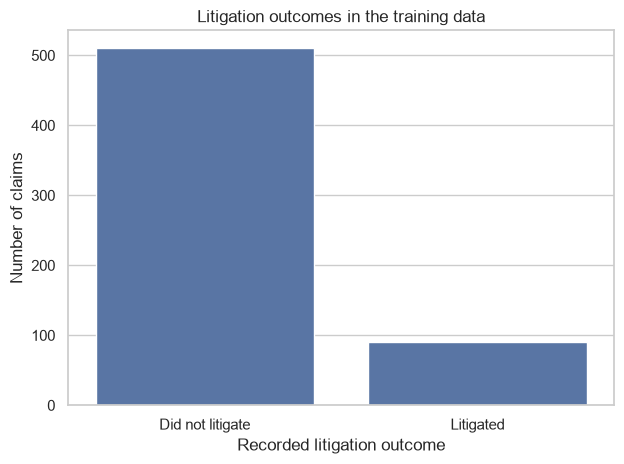

In [62]:
#Class balance chart for the training data. The target is binary, so a countplot is appropriate.

ax = sns.countplot(
    data=training_eda,
    x="litigated",
    order=[0, 1],
)

ax.set(
    title="Litigation outcomes in the training data",
    xlabel="Recorded litigation outcome",
    ylabel="Number of claims",
)
ax.set_xticks([0, 1], ["Did not litigate", "Litigated"])

plt.tight_layout()
plt.show()

The training data contains 90 litigated claims and 510 non-litigated
claims. Litigation is the minority outcome, representing 15% of claims.

This imbalance supports using precision, recall and average precision
rather than relying on accuracy alone.

In [63]:
# Summarise outcomes within each cause-of-loss group.
cause_summary = (
    training_eda.groupby("cause_of_loss", dropna=False)
    .agg(
        claims=("litigated", "size"),
        litigated_claims=("litigated", "sum"),
        litigation_rate=("litigated", "mean"),
    )
    .sort_values("litigation_rate", ascending=False)
)

cause_summary["litigation_percent"] = (
    100 * cause_summary["litigation_rate"]
)

display(
    cause_summary[
        ["claims", "litigated_claims", "litigation_percent"]
    ].round(1)
)

,claims,litigated_claims,litigation_percent
cause_of_loss,,,
Hail,86,23,26.7
Wind,126,25,19.8
Theft,53,8,15.1
Water,125,16,12.8
Hurricane,60,6,10.0
Vandalism,51,5,9.8
Freeze,31,3,9.7
Lightning,31,2,6.5
Fire,37,2,5.4


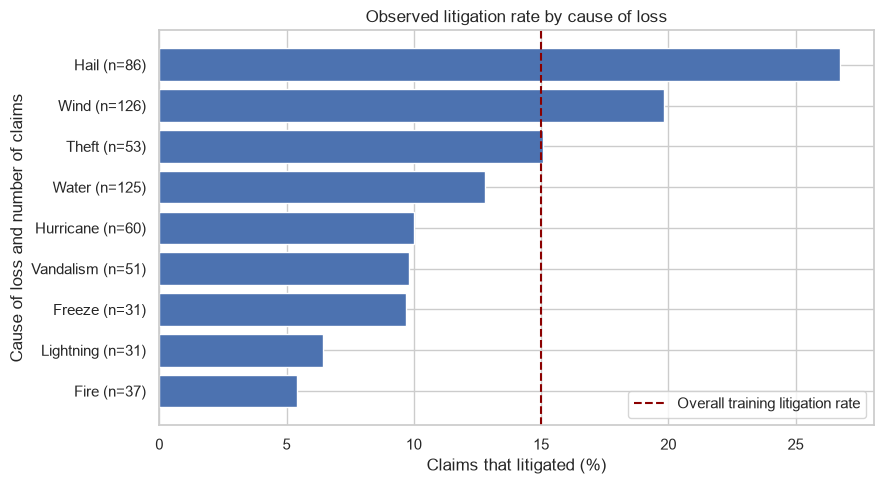

In [64]:
# Include group sizes so that small groups are not mistaken for strong evidence.
plot_data = cause_summary.reset_index()

labels = [
    f"{row.cause_of_loss} (n={row.claims})"
    for row in plot_data.itertuples()
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(labels, plot_data["litigation_percent"])
ax.invert_yaxis()

ax.axvline(
    100 * y_train.mean(),
    color="darkred",
    linestyle="--",
    label="Overall training litigation rate",
)

ax.set(
    title="Observed litigation rate by cause of loss",
    xlabel="Claims that litigated (%)",
    ylabel="Cause of loss and number of claims",
)

ax.legend()
plt.tight_layout()
plt.show()

In [65]:
# Summarise reporting delay separately for the two outcomes.
delay_summary = (
    training_eda.groupby("litigated")["reporting_delay_days"]
    .agg(
        available_values="count",
        median_days="median",
        mean_days="mean",
        maximum_days="max",
    )
)

display(delay_summary.round(1))

print(
    "Claims with missing reporting delay:",
    training_eda["reporting_delay_days"].isna().sum(),
)

,available_values,median_days,mean_days,maximum_days
litigated,,,,
0,510,5.0,7.2,50
1,90,7.5,14.9,50


Claims with missing reporting delay: 0


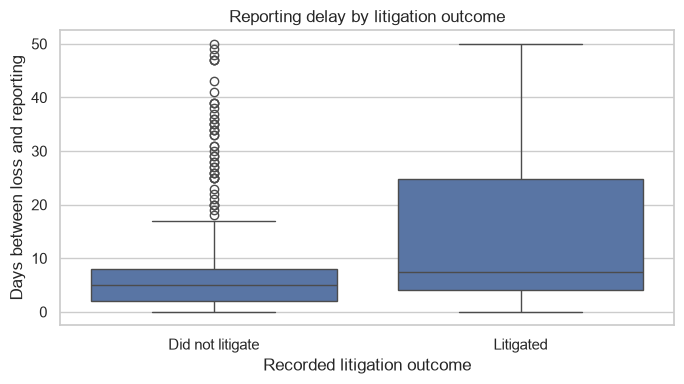

In [66]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(
    data=training_eda,
    x="litigated",
    y="reporting_delay_days",
    order=[0, 1],
    ax=ax,
)

ax.set(
    title="Reporting delay by litigation outcome",
    xlabel="Recorded litigation outcome",
    ylabel="Days between loss and reporting",
)
ax.set_xticks([0, 1], ["Did not litigate", "Litigated"])

plt.tight_layout()
plt.show()

In [67]:
# Identify missing predictors that preprocessing will need to handle.
training_missing = (
    X_train.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

training_missing["missing_percent"] = (
    100 * training_missing["missing_count"] / len(X_train)
).round(1)

display(
    training_missing.loc[
        training_missing["missing_count"] > 0
    ].sort_values("missing_count", ascending=False)
)

,missing_count,missing_percent


## Preprocessing and initial model comparison

We will compare three approaches:

- A dummy baseline that assigns every claim the training litigation rate.
- Logistic regression, which combines inputs into a classification score.
- Random forest, which combines many decision trees and can capture
  more complex relationships.

Preprocessing will be fitted using training data only. Missing numeric
values will be replaced with training medians, categorical values will
be encoded, and numeric inputs will be scaled for logistic regression.

Both predictive models will use class weighting to give the minority
litigation class greater influence during training.

We will compare validation performance. The test set remains untouched.

In [68]:
from time import perf_counter

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

In [ ]:
# This function creates instructions for preparing the data:
# - Imputation fills missing values using a rule learned from training data.
# - One-hot encoding turns categories into indicator columns—for example, a column indicating whether the roof is metal.
# - Scaling puts numeric inputs on comparable scales for logistic regression.
# - handle_unknown="ignore" lets the model process a category absent from training without crashing.

def make_preprocessor(scale_numeric=False):
    """Prepare numeric, categorical and binary inputs for a model."""

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]

    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)

    categorical_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Missing",
                ),
            ),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore"),
            ),
        ]
    )

    binary_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]
    )

    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, model_numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
            ("binary", binary_pipeline, binary_features),
        ],
        remainder="drop",
    )

In [ ]:
# Define the three models

models = {
    "Dummy baseline": Pipeline(
        [
            ("preprocessor", make_preprocessor()),
            ("model", DummyClassifier(strategy="prior")),
        ]
    ),

    #class_weight="balanced" gives more influence to litigation examples 
    # because they are less common. It does not create additional claims.
    "Logistic regression": Pipeline(
        [
            ("preprocessor", make_preprocessor(scale_numeric=True)),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "Random forest": Pipeline(
        [
            ("preprocessor", make_preprocessor()),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=150, #150 trees is a reasonable compromise between accuracy and speed
                    min_samples_leaf=5, #5 samples per leaf to avoid overfitting
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

In [71]:
#Fit on training data and evaluate on validation data. The test set is reserved for final evaluation.

fitted_models = {}
validation_scores = {}
comparison_rows = []

for name, pipeline in models.items():
    # Clone keeps the original model definitions unfitted and reusable.
    fitted_pipeline = clone(pipeline)

    start = perf_counter()
    fitted_pipeline.fit(X_train, y_train)
    fit_seconds = perf_counter() - start

    # Locate the probability column corresponding to litigation.
    positive_column = list(fitted_pipeline.classes_).index(1)

    scores = fitted_pipeline.predict_proba(
        X_validation
    )[:, positive_column]

    # Use a common initial threshold; we will examine alternatives later.
    predictions = (scores >= 0.5).astype(int)

    fitted_models[name] = fitted_pipeline
    validation_scores[name] = scores

    comparison_rows.append(
        {
            "model": name,
            "average_precision": average_precision_score(
                y_validation, scores
            ),
            "roc_auc": roc_auc_score(y_validation, scores),
            "precision": precision_score(
                y_validation, predictions, zero_division=0
            ),
            "recall": recall_score(
                y_validation, predictions, zero_division=0
            ),
            "f1": f1_score(
                y_validation, predictions, zero_division=0
            ),
            "accuracy": accuracy_score(y_validation, predictions),
            "flagged_claims": int(predictions.sum()),
            "fit_seconds": fit_seconds,
        }
    )

model_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
    .sort_values("average_precision", ascending=False)
)

display(model_comparison.round(3))

,average_precision,roc_auc,precision,recall,f1,accuracy,flagged_claims,fit_seconds
model,,,,,,,,
Logistic regression,0.385,0.649,0.219,0.533,0.311,0.645,73,0.068
Random forest,0.302,0.633,0.308,0.400,0.348,0.775,39,0.146
Dummy baseline,0.150,0.500,0.000,0.000,0.000,0.850,0,0.045


The initial comparison uses a common threshold of 0.5. This threshold
is a starting point rather than an agreed operational decision rule.

Class weighting can affect the interpretation of predicted scores.
They should not yet be presented as calibrated probabilities of litigation.

Model selection and threshold choices will use validation data only.

### Initial model results

Logistic regression achieved the highest validation average precision
(0.385), followed by random forest (0.302). Both exceeded the dummy
baseline (0.150), indicating useful ranking information in the inputs.

At the initial 0.5 threshold, logistic regression detected 16 of 30
litigated claims but flagged 73 claims overall. Random forest detected
12 of 30 while flagging 39 claims, providing higher precision with
lower recall.

The dummy achieved the highest accuracy but detected no litigated
claims, confirming that accuracy alone is unsuitable here.

Logistic regression is the provisional leader under our chosen metric.
We will tune both models and examine review workload before selecting
the final model and threshold. These are validation results, not final
test results.

## Model tuning and review threshold

We will evaluate six additional configurations using the existing
training and validation partitions.

The configuration with the highest validation average precision will
be selected. This small search limits runtime and reduces the temptation
to repeatedly optimise against the same validation data.

We will then choose a score threshold targeting approximately 20% of
validation claims for review. This is an illustrative capacity assumption,
not a business requirement supplied by Frontline.

In [77]:
# Change a few meaningful settings rather than running an extensive search.
tuning_candidates = [
    (
        "LR C=0.1",
        "Logistic regression",
        {"model__C": 0.1},
    ),
    (
        "LR C=0.5",
        "Logistic regression",
        {"model__C": 0.5},
    ),
    (
        "LR C=10",
        "Logistic regression",
        {"model__C": 10.0},
    ),
    (
        "RF depth=5 leaf=5",
        "Random forest",
        {"model__max_depth": 5, "model__min_samples_leaf": 5},
    ),
    (
        "RF depth=10 leaf=5",
        "Random forest",
        {"model__max_depth": 10, "model__min_samples_leaf": 5},
    ),
    (
        "RF depth=None leaf=10",
        "Random forest",
        {"model__max_depth": None, "model__min_samples_leaf": 10},
    ),
]

In [78]:
# Include the original predictive models so tuning must improve on them.
candidate_models = {
    name: fitted_models[name]
    for name in ["Logistic regression", "Random forest"]
}

candidate_scores = {
    name: validation_scores[name]
    for name in candidate_models
}

tuning_rows = [
    {
        "configuration": name,
        "average_precision": average_precision_score(
            y_validation, candidate_scores[name]
        ),
        "fit_seconds": model_comparison.loc[name, "fit_seconds"],
    }
    for name in candidate_models
]

for label, model_name, parameters in tuning_candidates:
    pipeline = clone(models[model_name]).set_params(**parameters)

    start = perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = perf_counter() - start

    positive_column = list(pipeline.classes_).index(1)
    scores = pipeline.predict_proba(
        X_validation
    )[:, positive_column]

    candidate_models[label] = pipeline
    candidate_scores[label] = scores

    tuning_rows.append(
        {
            "configuration": label,
            "average_precision": average_precision_score(
                y_validation, scores
            ),
            "fit_seconds": fit_seconds,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .set_index("configuration")
    .sort_values(
        "average_precision",
        ascending=False,
        kind="stable",
    )
)

display(tuning_results.round(4))

,average_precision,fit_seconds
configuration,,
LR C=0.5,0.3915,0.0135
LR C=0.1,0.3889,0.0204
Logistic regression,0.3850,0.0678
LR C=10,0.3583,0.0118
RF depth=10 leaf=5,0.3153,0.1237
RF depth=None leaf=10,0.3118,0.1179
RF depth=5 leaf=5,0.3067,0.1267
Random forest,0.3017,0.1462


In [79]:
# Select using unrounded validation scores.
selected_name = tuning_results.index[0]
selected_model = candidate_models[selected_name]
selected_validation_scores = candidate_scores[selected_name]

print("Selected configuration:", selected_name)
print(
    "Validation average precision:",
    round(tuning_results.iloc[0]["average_precision"], 4),
)

Selected configuration: LR C=0.5
Validation average precision: 0.3915


In [80]:
def summarise_threshold(threshold, scores, target):
    """Describe detection performance and workload at one score cutoff."""
    predictions = (scores >= threshold).astype(int)

    return {
        "threshold": threshold,
        "flagged_claims": int(predictions.sum()),
        "flagged_percent": 100 * predictions.mean(),
        "litigated_detected": int(
            ((predictions == 1) & (target.to_numpy() == 1)).sum()
        ),
        "precision": precision_score(
            target, predictions, zero_division=0
        ),
        "recall": recall_score(
            target, predictions, zero_division=0
        ),
        "f1": f1_score(
            target, predictions, zero_division=0
        ),
    }


threshold_comparison = pd.DataFrame(
    [
        summarise_threshold(
            threshold,
            selected_validation_scores,
            y_validation,
        )
        for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    ]
)

display(threshold_comparison.round(3))

,threshold,flagged_claims,flagged_percent,litigated_detected,precision,recall,f1
0,0.2,161,80.5,26,0.161,0.867,0.272
1,0.3,130,65.0,22,0.169,0.733,0.275
2,0.4,99,49.5,20,0.202,0.667,0.310
3,0.5,71,35.5,16,0.225,0.533,0.317
4,0.6,52,26.0,15,0.288,0.500,0.366
5,0.7,28,14.0,12,0.429,0.400,0.414
6,0.8,15,7.5,6,0.400,0.200,0.267


In [81]:
REVIEW_CAPACITY = 0.20

# Include a cutoff above the maximum to represent flagging no claims.
possible_thresholds = np.append(
    np.unique(selected_validation_scores),
    np.nextafter(selected_validation_scores.max(), np.inf),
)

capacity_options = pd.DataFrame(
    [
        summarise_threshold(
            threshold,
            selected_validation_scores,
            y_validation,
        )
        for threshold in possible_thresholds
    ]
)

capacity_options["distance_from_capacity"] = (
    capacity_options["flagged_percent"] - 100 * REVIEW_CAPACITY
).abs()

# Choose the closest workload; prefer fewer alerts if equally close.
chosen_option = (
    capacity_options.sort_values(
        ["distance_from_capacity", "flagged_claims"]
    )
    .iloc[0]
)

selected_threshold = float(chosen_option["threshold"])

display(
    chosen_option.drop("distance_from_capacity")
    .to_frame("validation_result")
    .round(3)
)

print("Frozen model:", selected_name)
print("Frozen threshold:", selected_threshold)

,validation_result
threshold,0.643
flagged_claims,40.000
flagged_percent,20.000
litigated_detected,14.000
precision,0.350
recall,0.467
f1,0.400


Frozen model: LR C=0.5
Frozen threshold: 0.6427487526888729


The model configuration and score threshold were selected using
validation data only.

The chosen threshold targets approximately 20% review workload on
validation data. Actual workload on new claims may differ.

We will now retain this fitted model and threshold unchanged for final
test evaluation. We will not refit on combined training and validation
data, because refitting could change the scores underlying the cutoff.

### Selected model and operating threshold

The tuning procedure selected logistic regression with C=0.5.
A validation score threshold of approximately 0.643 meets the
illustrative review capacity of 20%.

At this threshold, 40 validation claims are flagged, including 14
that litigated. Precision is 35% and recall is 46.7%. There are
26 false alarms and 16 missed litigation cases.

The flagged group contains approximately 2.3 times the overall
proportion of litigated claims. However, more than half of litigation
cases remain undetected at this workload.

This threshold was chosen to match review capacity, not to maximise
F1. The score is not a calibrated probability, so 0.643 should not
be interpreted as a 64.3% chance of litigation.

The fitted model and full-precision threshold are now fixed for
final test evaluation. Validation findings are provisional.

## Final test evaluation

We now evaluate the selected model on the 200 held-out test claims.

The model and review threshold were selected using validation data.
Neither will be changed in response to test performance.

We report ranking performance, detection performance and review workload.
The confusion matrix shows the actual numbers of correct predictions,
false alarms and missed litigation cases.

In [82]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
)

# Apply the already-fitted model; do not call fit again.
positive_column = list(selected_model.classes_).index(1)

test_scores = selected_model.predict_proba(
    X_test
)[:, positive_column]

test_predictions = (
    test_scores >= selected_threshold
).astype(int)

test_results = pd.DataFrame(
    [
        {
            "model": selected_name,
            "threshold": selected_threshold,
            "test_claims": len(y_test),
            "litigated_claims": int(y_test.sum()),
            "average_precision": average_precision_score(
                y_test, test_scores
            ),
            "roc_auc": roc_auc_score(y_test, test_scores),
            "precision": precision_score(
                y_test, test_predictions, zero_division=0
            ),
            "recall": recall_score(
                y_test, test_predictions, zero_division=0
            ),
            "f1": f1_score(
                y_test, test_predictions, zero_division=0
            ),
            "accuracy": accuracy_score(y_test, test_predictions),
            "flagged_claims": int(test_predictions.sum()),
            "flagged_percent": 100 * test_predictions.mean(),
        }
    ]
)

display(test_results.set_index("model").round(3))

,threshold,test_claims,litigated_claims,average_precision,roc_auc,precision,recall,f1,accuracy,flagged_claims,flagged_percent
model,,,,,,,,,,,
LR C=0.5,0.643,200,30,0.232,0.543,0.171,0.233,0.197,0.715,41,20.5


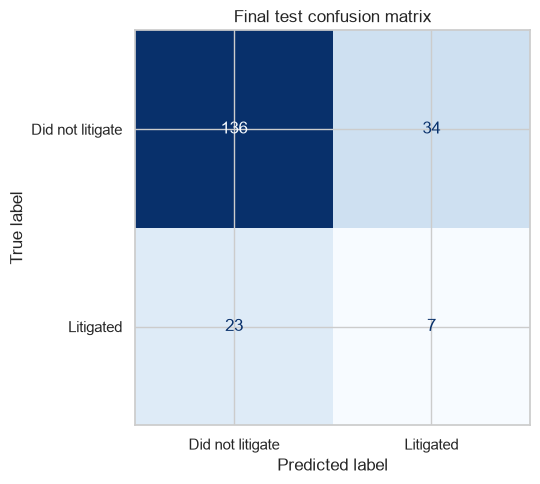

In [83]:
# Rows represent actual outcomes; columns represent model decisions.
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not litigate", "Litigated"],
)

fig, ax = plt.subplots(figsize=(6, 5))

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title("Final test confusion matrix")
plt.tight_layout()
plt.show()

In [84]:
true_negatives, false_positives, false_negatives, true_positives = (
    cm.ravel()
)

print(
    f"Of {len(y_test)} test claims, "
    f"{true_positives + false_positives} were flagged for review."
)
print(f"Detected litigation cases: {true_positives}")
print(f"False alarms: {false_positives}")
print(f"Missed litigation cases: {false_negatives}")
print(f"Correctly unflagged non-litigated claims: {true_negatives}")

Of 200 test claims, 41 were flagged for review.
Detected litigation cases: 7
False alarms: 34
Missed litigation cases: 23
Correctly unflagged non-litigated claims: 136


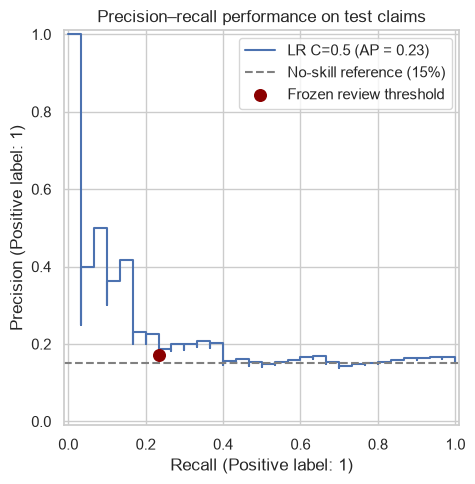

In [85]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_scores,
    name=selected_name,
    ax=ax,
)

# The prevalence line provides a no-skill reference.
ax.axhline(
    y_test.mean(),
    color="grey",
    linestyle="--",
    label=f"No-skill reference ({y_test.mean():.0%})",
)

# Mark the operating point selected earlier using validation data.
ax.scatter(
    recall_score(y_test, test_predictions),
    precision_score(
        y_test, test_predictions, zero_division=0
    ),
    color="darkred",
    s=70,
    zorder=3,
    label="Frozen review threshold",
)

ax.set_title("Precision–recall performance on test claims")
ax.legend()
plt.tight_layout()
plt.show()

### Final test findings

At the frozen threshold, the model flagged 41 of 200 test claims
(20.5%). It identified 7 of 30 litigated claims, giving precision
of 17.1% and recall of 23.3%. There were 34 false alarms and
23 missed litigation cases.

Test average precision was approximately 0.23, above the 0.15
no-skill reference. However, performance at the selected operating
threshold was substantially weaker than on validation data.

The difference may reflect sampling variability and selection against
a small validation set. These results alone do not establish its cause.

The findings do not justify operational deployment. Further evaluation
on larger, time-separated data and verification of feature availability
are needed. The model and threshold have not been changed after
examining test results.

## Model interpretation

We use permutation importance to examine which inputs the fitted
model relies on.

For each input, we randomly shuffle its values across validation
claims and measure the change in average precision. Shuffling breaks
the connection between that input and the claim outcome.

We repeat this five times per input. Larger average performance drops
indicate greater reliance on that feature.

This analysis explains the existing model. It will not be used to
change the model after final test evaluation.

In [86]:
from sklearn.inspection import permutation_importance

# Assess the frozen pipeline on validation data without retraining it.
importance_result = permutation_importance(
    selected_model,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = pd.DataFrame(
    {
        "feature": X_validation.columns,
        "mean_ap_drop": importance_result.importances_mean,
        "std_ap_drop": importance_result.importances_std,
    }
).sort_values("mean_ap_drop", ascending=False)

display(feature_importance.round(4))

,feature,mean_ap_drop,std_ap_drop
8,reporting_delay_days,0.2087,0.0404
9,deductible_to_coverage,0.1584,0.0129
11,cause_of_loss,0.0918,0.0312
6,deductible,0.0560,0.0178
12,roof_material,0.0428,0.0159
3,property_value,0.0400,0.0142
5,coverage_a_limit,0.0208,0.0074
10,coverage_to_property_value,0.0097,0.0020
0,property_age,0.0052,0.0015
7,annual_premium,0.0020,0.0039


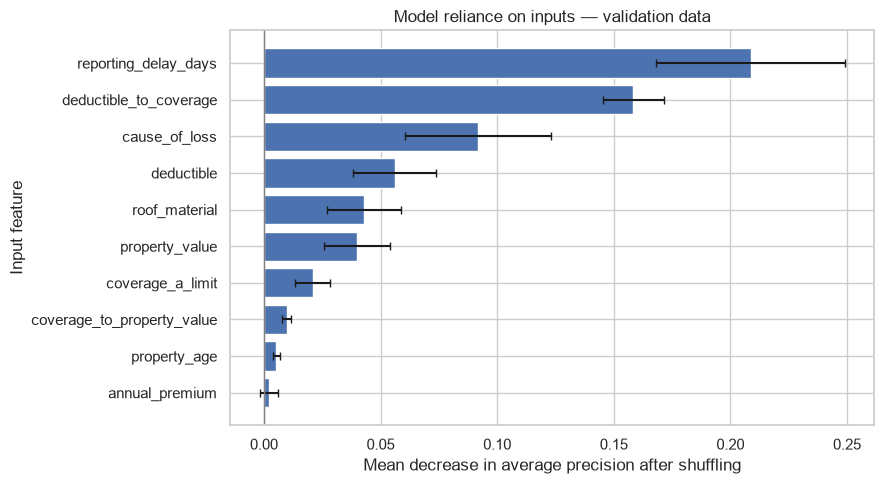

In [87]:
# Reverse the plotting order so the most important feature appears at the top.
top_features = (
    feature_importance.head(10)
    .sort_values("mean_ap_drop")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    top_features["feature"],
    top_features["mean_ap_drop"],
    xerr=top_features["std_ap_drop"],
    capsize=3,
)

ax.axvline(0, color="grey", linewidth=1)

ax.set(
    title="Model reliance on inputs — validation data",
    xlabel="Mean decrease in average precision after shuffling",
    ylabel="Input feature",
)

plt.tight_layout()
plt.show()

### Interpretation of feature importance

Reporting delay produced the largest mean decrease in validation
average precision when shuffled (0.209), followed by the
deductible-to-coverage ratio (0.158) and cause of loss (0.092).
The fitted model therefore relies particularly on these inputs.

These results describe model reliance, not causal effects or the
direction of a relationship. Importance values are not additive.

Financial ratios and their underlying inputs are related, so
independently shuffling them may create unrealistic combinations.
Their individual importance estimates should be interpreted cautiously.

Several features showed near-zero or negative importance. These
findings could inform a future modelling experiment, but no features
will be removed from the evaluated model.

The error bars show variation across five shuffles, not confidence
intervals. These validation explanations do not overcome the weak
performance observed on the final test set.

## Conclusions and recommendations

### Approach

We built an intake-time litigation prediction proof of concept using
synthetic home insurance claims.

All six supplied files were audited. The initial model used selected
fields from claims.csv, which already contains property and policy
information. Other sources were excluded from prediction where
availability at first notification was uncertain.

We engineered reporting delay and two financial ratios, then compared
a dummy baseline, logistic regression and random forest. Preprocessing
was fitted on training data only, with separate validation and test sets.

A bounded tuning exercise selected logistic regression with C=0.5.
A validation threshold of approximately 0.643 was chosen to target an
illustrative review workload of 20%.

### Findings

On validation data, reviewing 40 claims identified 14 of 30 litigation
cases. Precision was 35% and recall was 46.7%.

On the held-out test set, the same model and threshold flagged 41
claims but identified only 7 of 30 litigation cases. Precision fell
to 17.1% and recall to 23.3%. There were 34 false alarms and 23
missed litigation cases.

Test average precision was approximately 0.23, above the 0.15
no-skill reference. However, the limited benefit at the selected
review threshold does not establish operational usefulness.

Validation permutation importance indicated greatest reliance on
reporting delay, deductible relative to coverage, and cause of loss.
These findings describe the model's behaviour, not causes of litigation.

### Recommendation

Do not deploy the current model into operational decision-making.

The exercise demonstrates a reproducible modelling workflow, but the
validation performance did not carry through strongly to the test set.
Further work should establish whether useful ranking performance can
be reproduced on larger, representative data.

The evaluated model and threshold remain unchanged following test
evaluation.

### Limitations

- The data is synthetic, so results may not represent real claims.
- Validation and test sets each contain only 30 litigation cases,
  making performance estimates sensitive to individual outcomes.
- Model selection used the validation set repeatedly, so its results
  may be optimistic.
- Random splitting does not establish performance on future claims.
  Shared catastrophe events may also create similarities across splits.
- Intake availability of the selected property and policy snapshots
  remains an assumption requiring confirmation.
- The target has no verified fixed prediction horizon or complete
  follow-up definition.
- Class-weighted model scores have not been calibrated as probabilities.
- Additional data sources were not incorporated where their timing
  could not be established confidently.

### Prioritised next steps

1. Confirm the prediction point, input availability and litigation
   outcome definition with Claims experts.
2. Agree review capacity and the relative consequences of missed
   litigation cases and unnecessary reviews.
3. Obtain more representative claims with sufficient outcome follow-up.
   Evaluate using chronological splits and consider catastrophe grouping.
4. In a new development cycle, investigate simpler feature sets and
   historical aggregates verified as available at prediction time.
   Reserve a new untouched evaluation period.
5. Explore intake-only claim notes if their availability is verified.
   Compare any NLP or LLM extension against the structured baseline,
   checking extracted information for accuracy and leakage.

### Proposed production approach

If subsequent evidence supports a pilot, version the code, input
schema, data snapshot and fitted preprocessing/model pipeline.

A possible AWS implementation would use controlled S3 storage and
a managed training and batch-scoring service such as SageMaker.
Automated checks would verify input schemas, feature timing and
reproducibility before releasing changes.

Monitoring would cover missing values, changes in input distributions,
review workload and model performance once outcomes become available.
Retraining would require evaluation and approval, with a previous
model available for rollback.

This is a proposed deployment approach; AWS deployment, CI/CD and
production monitoring were not implemented in this exercise.

### Proposed Agentic System

Subsequently, this could be expanded upon to produce an agent assisted workflow that provides tools such as: 

- Intake and cutoff agent: For schema checks and  data parser -> Validated Day-30 claim packet
- Note evidence agent: For controlled taxonomy and source note retrieval -> Cited themes and leakage flags
- Risk and quality agent: Model scoring and reason codes / Drift and Calibration Checks -> Risk score with quality status
- Claims review workspace: Review queue and evidence links / Audit -> Human-owned review decision

With controls at every stage such as:  access control, minimal personal data, prompt and model version logs, human approval and performance monitoring 